# Leave-One-Center-Out Cross Validation — Per-Center Performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Optional, Tuple
from matplotlib import font_manager, rcParams

# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"

In [5]:
def plot_center_performance(
    df: pd.DataFrame,
    meta_models: List[str],
    *,
    original_models: Optional[List[str]] = None,
    low_label: str = "GDD_accuracy",
    metric: str = "accuracy",
    rename_map: Optional[Dict[str, str]] = None,
    sort_by: str = "improvement_percentage",
    figsize: Tuple[int, int] = (10, 12),
    show_table: bool = True,
    output_prefix: str = "meta_model_loco_cv",
) -> pd.DataFrame:
    """
    Horizontal dot plot of per-center metric values ranked by improvement over a baseline.

    Parameters
    ----------
    df            : Must contain 'CENTER', 'num_test_samples', `low_label`, and all model columns.
    meta_models   : Meta-model column names to plot.
    original_models: Baseline column names (default: GDD + GPT-5 if present).
    low_label     : Baseline column for computing improvement.
    metric        : 'accuracy' (x-axis 0-100) or 'f1' (x-axis 0-1).
    rename_map    : Display names keyed by column name.
    sort_by       : 'improvement_percentage' or 'improvement'.
    figsize       : Figure dimensions.
    show_table    : Print ranking table and insights.
    output_prefix : File prefix for saved PDFs/PNGs.

    Returns
    -------
    df_sorted : DataFrame augmented with improvement columns, sorted by sort_by.
    """
    if rename_map is None:
        rename_map = {
            f"GDD_{metric}":          "GDD-ENS",
            f"gpt_5_{metric}":        "GPT-5",
            f"LogReg_{metric}":       "LogReg",
            f"XGBoost_{metric}":      "XGBoost",
            f"RandomForest_{metric}": "Random Forest",
        }
    if original_models is None:
        original_models = [
            c for c in [f"GDD_{metric}", f"gpt_5_{metric}"] if c in df.columns
        ]

    required = {"CENTER", "num_test_samples", low_label}
    missing  = required - set(df.columns)
    if missing:
        raise ValueError(f"df missing required columns: {sorted(missing)}")
    for c in original_models + meta_models:
        if c not in df.columns:
            raise ValueError(f"Column '{c}' not found in df.")
    if sort_by not in {"improvement_percentage", "improvement"}:
        raise ValueError("sort_by must be 'improvement_percentage' or 'improvement'")

    # Compute improvement metrics
    meta_max     = df[meta_models].max(axis=1) if meta_models else df[low_label].copy()
    improvements = meta_max - df[low_label]

    df_sorted = df.copy()
    df_sorted["original_mean"] = df[original_models].mean(axis=1) if original_models else df[low_label]
    df_sorted["meta_max"]      = meta_max
    df_sorted["improvement"]   = improvements
    df_sorted["improvement_percentage"] = np.where(
        df_sorted[low_label] != 0,
        improvements / df_sorted[low_label] * 100.0,
        np.nan,
    )
    df_sorted = df_sorted.sort_values(sort_by, ascending=False).reset_index(drop=True)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    ax.invert_yaxis()

    offset = 0.17
    centers = df_sorted["CENTER"].values
    y_pos   = np.arange(len(centers)) - offset

    # Baseline dots
    baseline_styles = [
        (f"GDD_{metric}",   "#ff4444", "o", "darkred"),
        (f"gpt_5_{metric}", "#ffc067", "o", "darkred"),
    ]
    for col, color, marker, edge in baseline_styles:
        if col in original_models:
            ax.scatter(
                df_sorted[col], y_pos,
                color=color, s=120, alpha=0.7,
                label=rename_map.get(col, col),
                marker=marker, zorder=3, edgecolors=edge, linewidth=1.5,
            )

    # Meta-model dots
    color_pool  = ["#4444ff", "#44ff44", "#ff44ff", "#00cccc", "#cc8800", "#8844ff"]
    marker_pool = ["^", "s", "D", "P", "X", "*"]
    for i, col in enumerate(meta_models):
        ax.scatter(
            df_sorted[col], y_pos,
            color=color_pool[i % len(color_pool)], s=80, alpha=0.8,
            label=rename_map.get(col, col),
            marker=marker_pool[i % len(marker_pool)],
            zorder=4, edgecolors="black", linewidth=0.5,
        )

    # Improvement lines and annotations
    for i in range(len(centers)):
        if not meta_models:
            continue
        x0 = float(df_sorted[low_label].iloc[i])
        x1 = float(df_sorted["meta_max"].iloc[i])
        ax.plot([x0, x1], [i - offset, i - offset], "g-", alpha=0.4, linewidth=2, zorder=1)

        imp     = df_sorted["improvement"].iloc[i]
        base    = df_sorted[low_label].iloc[i]
        imp_pct = (imp / base * 100.0) if base else np.nan

        if pd.isna(imp_pct):
            text = "n/a"
        else:
            sign = "+" if imp_pct >= 0 else ""
            text = f"{sign}{imp_pct:.1f}%"

        ax.text((x0 + x1) / 2, i + 0.4, text,
                fontsize=14, ha="center", va="bottom",
                color="black", fontweight="normal")

    # Row background shading
    for i in range(len(centers)):
        ax.axhspan(i - 0.4, i + 0.4, xmin=0, xmax=1,
                   color="blue", alpha=0.15, zorder=0)

    center_to_n  = dict(zip(df_sorted["CENTER"], df_sorted["num_test_samples"]))
    ytick_labels = [f"{c} (N={center_to_n.get(c, 'NA')})" for c in centers]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ytick_labels, fontsize=16, va="top")

    ax.set_xlabel(f"{metric} (%)", fontsize=16, fontweight="bold") if metric == "accuracy" else \
        ax.set_xlabel(metric, fontsize=16, fontweight="bold")
    ax.set_ylabel("Center", fontsize=16, fontweight="bold")
    ax.tick_params(axis="x", labelsize=16)
    ax.set_xlim(0, 100) if metric == "accuracy" else ax.set_xlim(0, 1)
    ax.margins(y=0)

    sort_label = "% Improvement" if sort_by == "improvement_percentage" else "Absolute Improvement"
    ax.set_title(
        f"Leave-one-center-out Cross Validation",
        fontsize=16, fontweight="bold", pad=4,
    )

    handles, lbls = ax.get_legend_handles_labels()
    lbl_to_handle = {l: h for h, l in zip(handles, lbls)}
    desired = [
        rename_map.get(c, c)
        for c in [f"GDD_{metric}", f"gpt_5_{metric}"] + meta_models
        if rename_map.get(c, c) in lbl_to_handle
    ]
    ax.legend(
        [lbl_to_handle[l] for l in desired], desired,
        loc="upper right", fontsize=16, framealpha=0.95,
        title="Models", title_fontsize=16,
    )

    plt.tight_layout()
    plt.savefig(f"{output_prefix}_{metric}.pdf")
    plt.savefig(f"{output_prefix}_{metric}.png")
    plt.show()

    # Ranking table
    if show_table:
        print("\n" + "=" * 80)
        print("CENTERS RANKED BY IMPROVEMENT")
        print("=" * 80)
        print(f"{'Rank':<6} {'Center':<14} {'Baseline':<10} {'Best Meta':<10} "
              f"{'Improvement':<12} {'% Gain':<8} {'Best Model':<20} {'Samples':<10}")
        print("-" * 80)
        for rank, (_, row) in enumerate(df_sorted.iterrows(), 1):
            best_name = rename_map.get(row[meta_models].idxmax(), "") if meta_models else "—"
            base = row[low_label]
            pct  = (row["improvement"] / base * 100.0) if base else np.nan
            pct_str = f"{pct:.1f}%" if not pd.isna(pct) else "n/a"
            print(f"{rank:<6} {row['CENTER']:<14} {base:<10.4f} "
                  f"{row['meta_max']:<10.4f} {row['improvement']:<12.4f} "
                  f"{pct_str:<8} {best_name:<20} {row['num_test_samples']:<10}")
        print("-" * 80)
        base_mean = df_sorted[low_label].mean()
        mean_imp  = df_sorted["improvement"].mean()
        mean_pct  = (mean_imp / base_mean * 100.0) if base_mean else np.nan
        print(f"{'AVERAGE:':<16} {base_mean:<10.4f} {df_sorted['meta_max'].mean():<10.4f} "
              f"{mean_imp:<12.4f} {f'{mean_pct:.1f}%' if not pd.isna(mean_pct) else 'n/a'}")

    return df_sorted

## F1 — LogReg vs GDD-ENS baseline

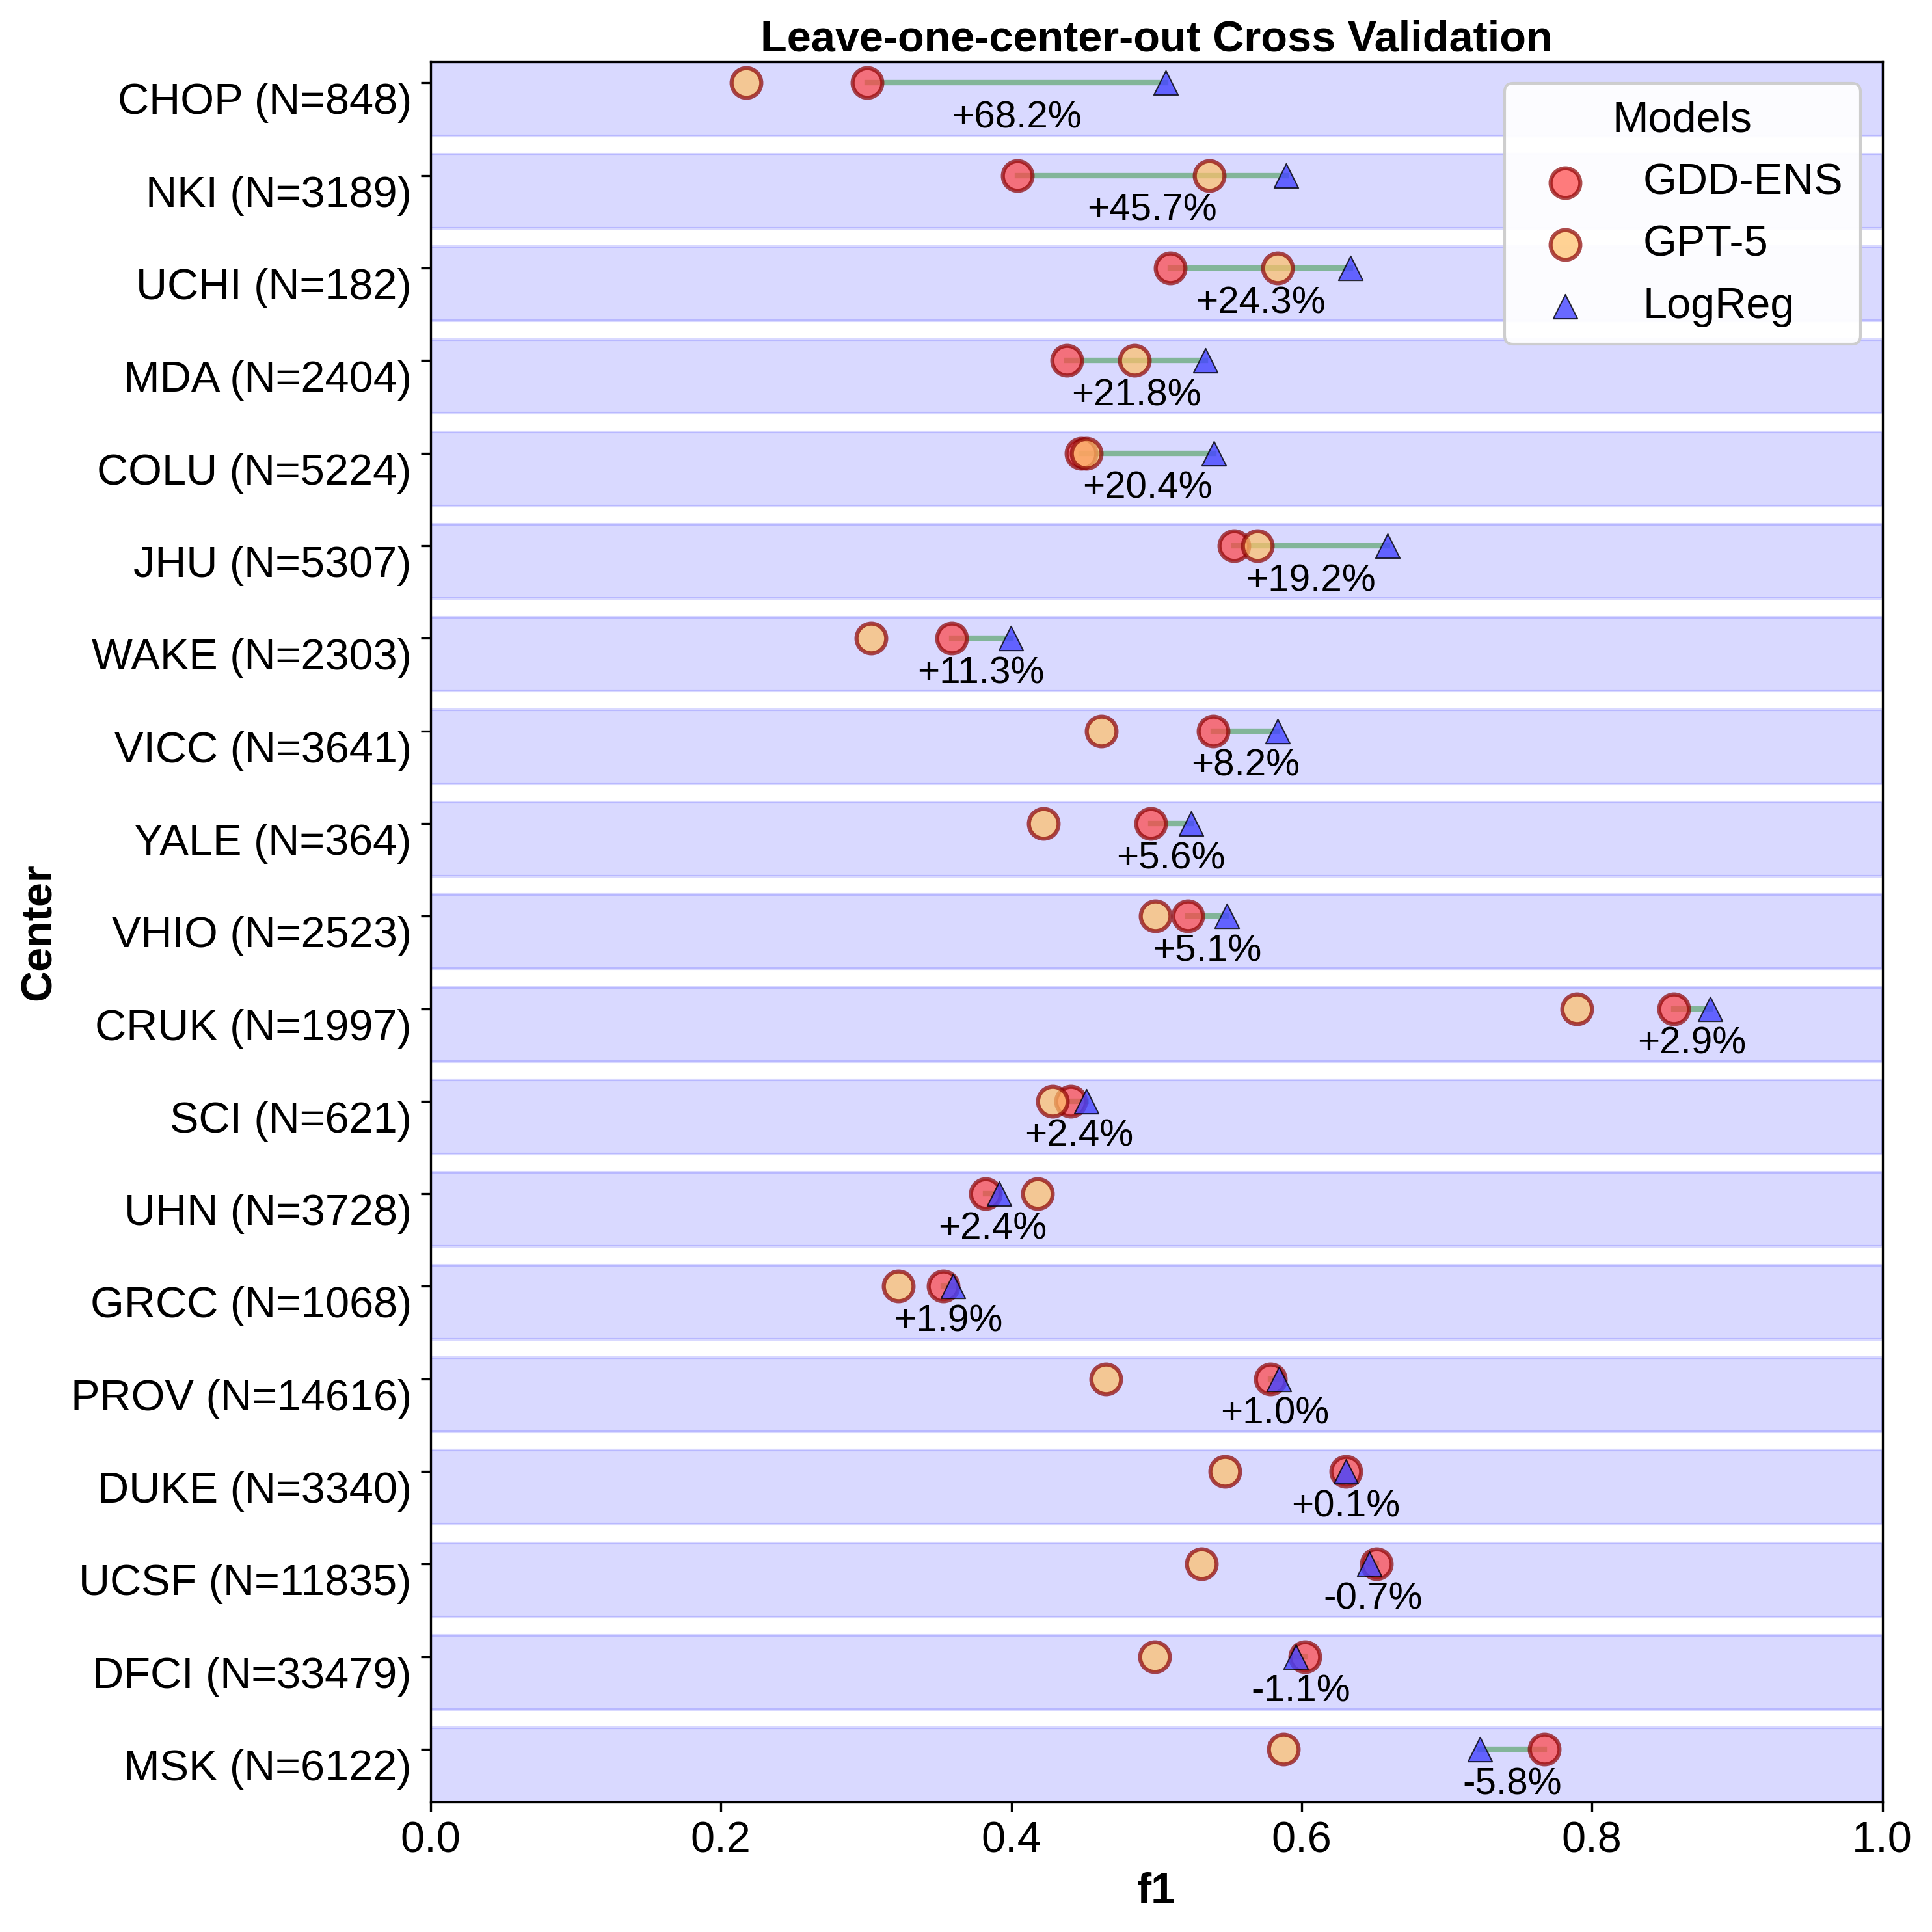


CENTERS RANKED BY IMPROVEMENT
Rank   Center         Baseline   Best Meta  Improvement  % Gain   Best Model           Samples   
--------------------------------------------------------------------------------
1      CHOP           0.3009     0.5062     0.2053       68.2%    LogReg               848       
2      NKI            0.4044     0.5892     0.1848       45.7%    LogReg               3189      
3      UCHI           0.5097     0.6338     0.1241       24.3%    LogReg               182       
4      MDA            0.4382     0.5337     0.0955       21.8%    LogReg               2404      
5      COLU           0.4483     0.5397     0.0914       20.4%    LogReg               5224      
6      JHU            0.5534     0.6594     0.1060       19.2%    LogReg               5307      
7      WAKE           0.3589     0.3996     0.0407       11.3%    LogReg               2303      
8      VICC           0.5391     0.5832     0.0441       8.2%     LogReg               3641      
9     

In [6]:
df = pd.read_csv('/data1/morrisq/yuj13/llm_genomics/genie_meta_model_result/20251206_230739_gpt5_10fold/leave_one_center_out_detailed_results.csv')

_ = plot_center_performance(
    df,
    meta_models=["LogReg_f1"],
    low_label="GDD_f1",
    metric="f1",
    rename_map={
        "GDD_f1":    "GDD-ENS",
        "gpt_5_f1":  "GPT-5",
        "LogReg_f1": "LogReg",
    },
    figsize=(10, 10),
)

## Accuracy — LogReg vs GDD-ENS baseline

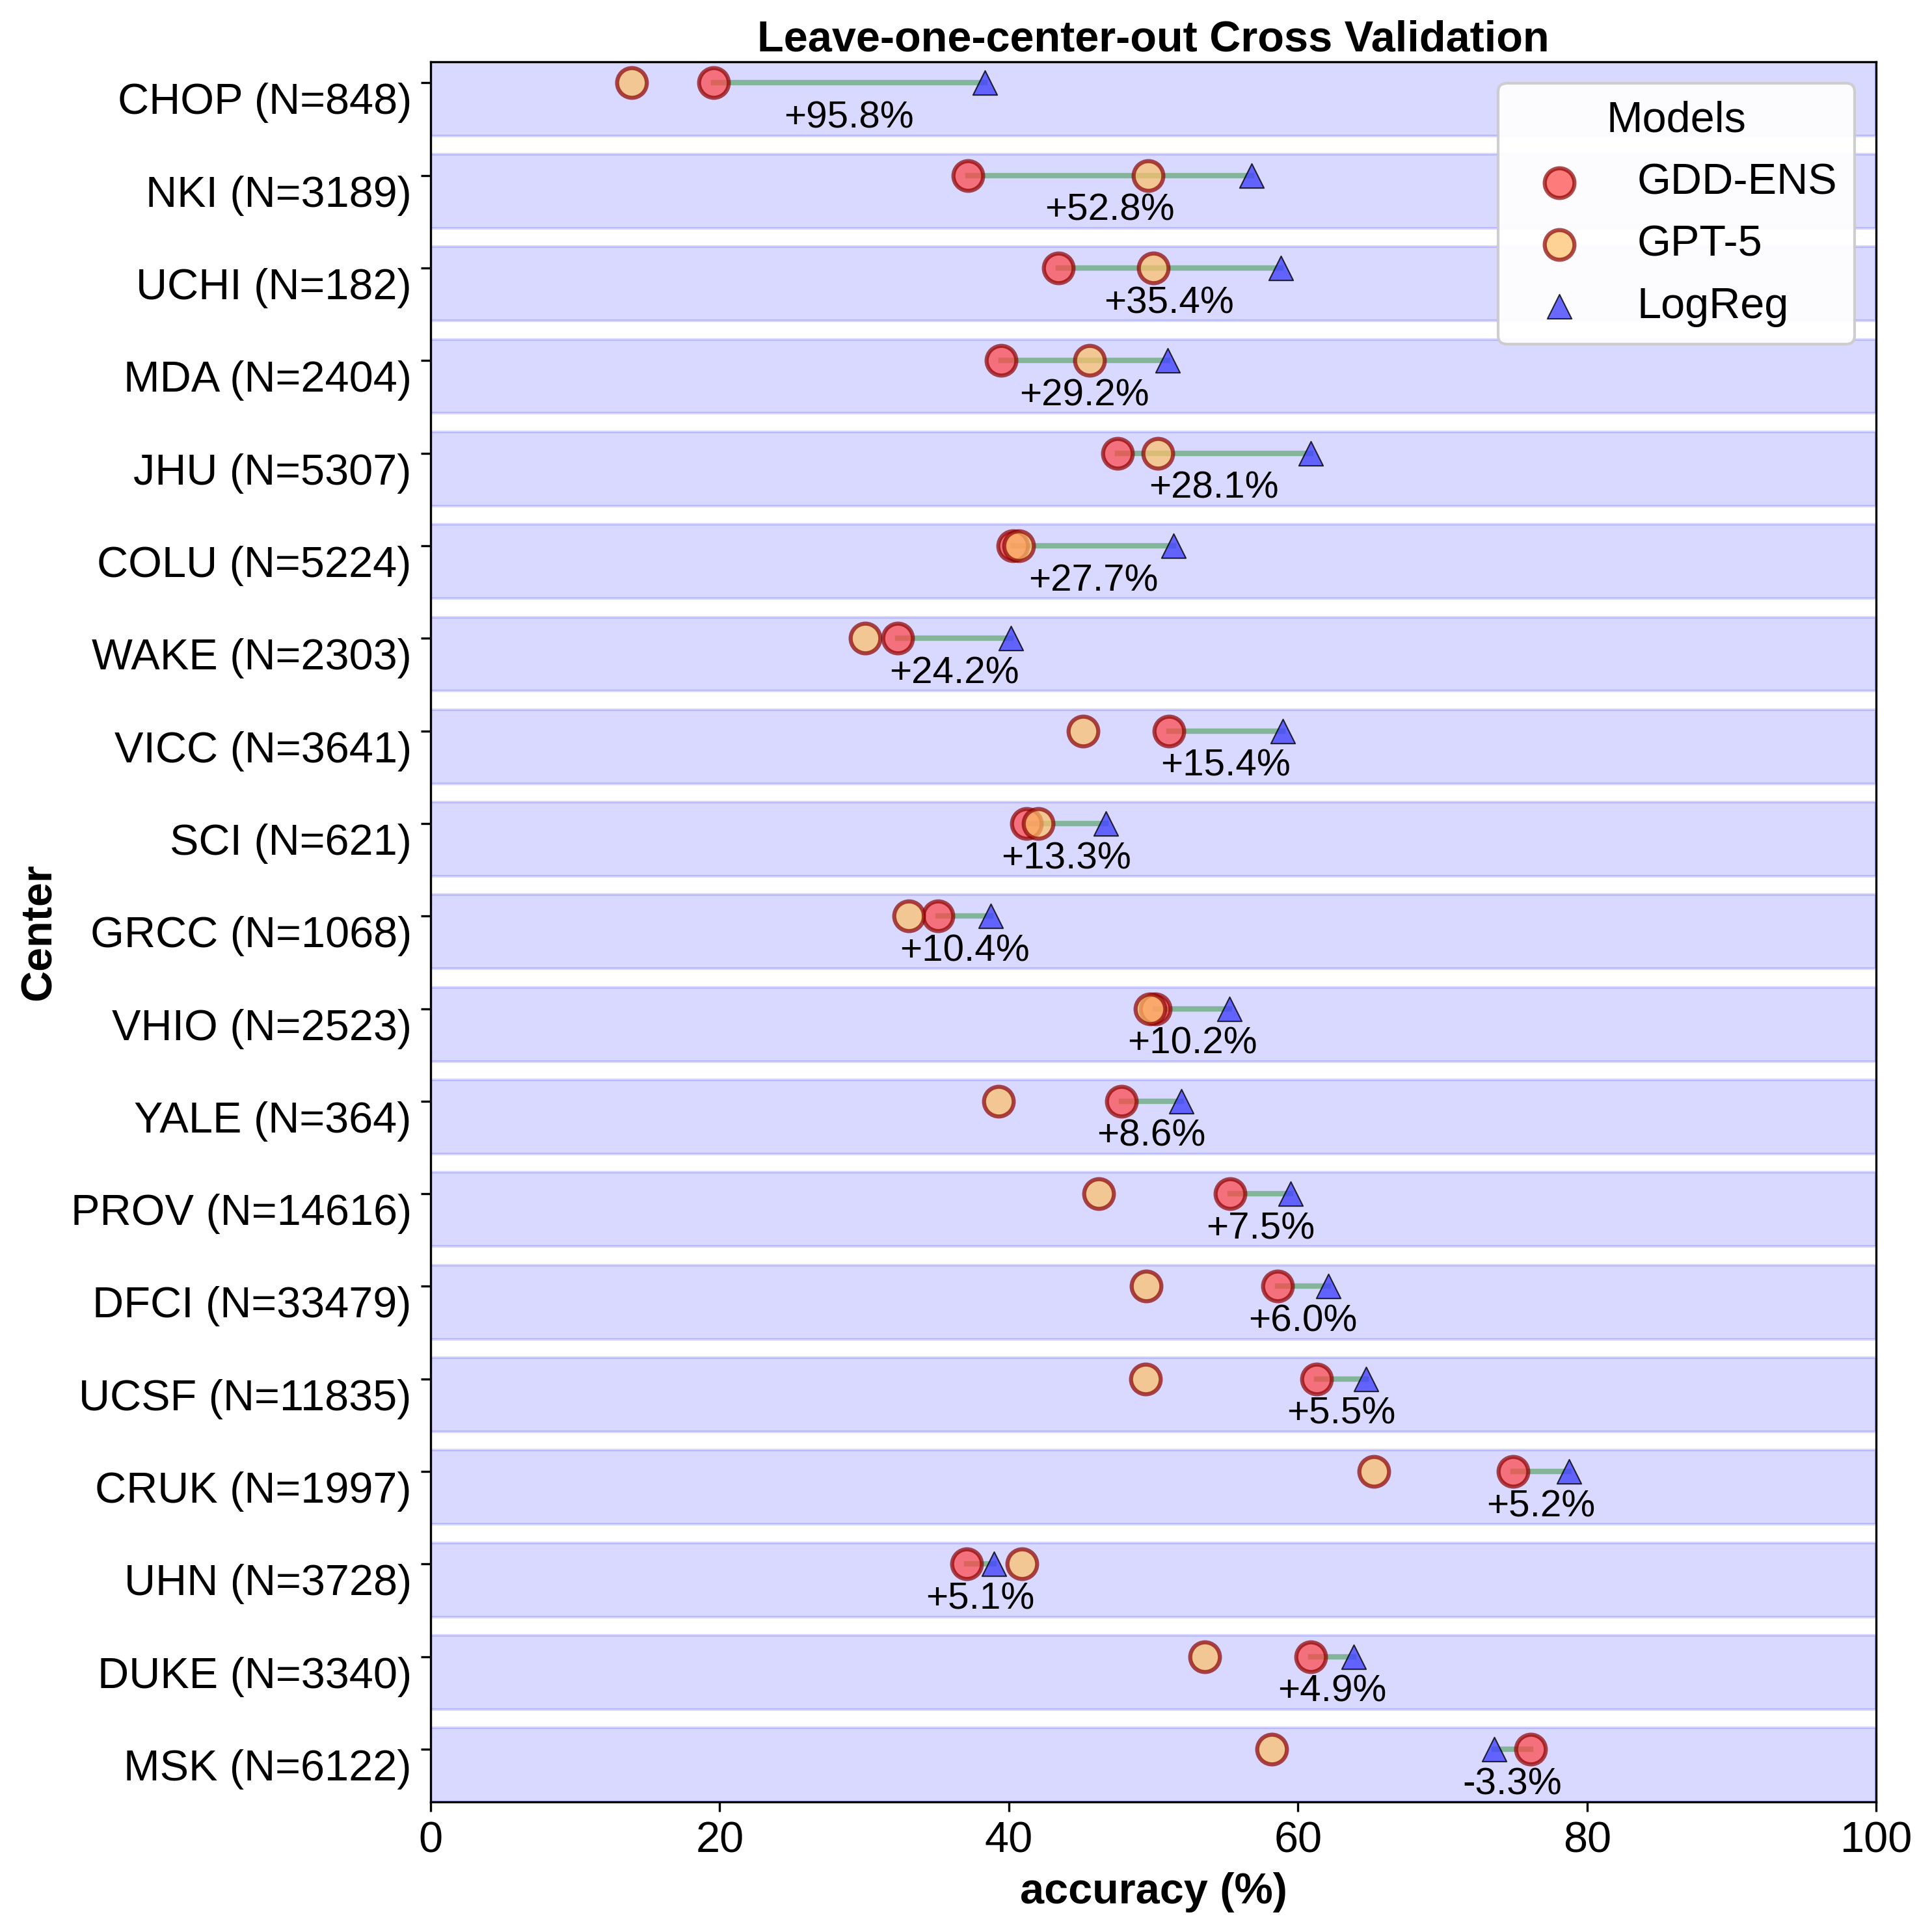


CENTERS RANKED BY IMPROVEMENT
Rank   Center         Baseline   Best Meta  Improvement  % Gain   Best Model           Samples   
--------------------------------------------------------------------------------
1      CHOP           19.5755    38.3255    18.7500      95.8%    LogReg               848       
2      NKI            37.1590    56.7890    19.6300      52.8%    LogReg               3189      
3      UCHI           43.4066    58.7912    15.3846      35.4%    LogReg               182       
4      MDA            39.4759    50.9983    11.5225      29.2%    LogReg               2404      
5      JHU            47.5221    60.8630    13.3409      28.1%    LogReg               5307      
6      COLU           40.2565    51.3974    11.1409      27.7%    LogReg               5224      
7      WAKE           32.3057    40.1216    7.8159       24.2%    LogReg               2303      
8      VICC           51.0574    58.9399    7.8824       15.4%    LogReg               3641      
9     

In [7]:
acc_cols = [c for c in df.columns if "accuracy" in c.lower()]
df_acc = df.copy()
df_acc[acc_cols] = df_acc[acc_cols] * 100  # scale to percentage

_ = plot_center_performance(
    df_acc,
    meta_models=["LogReg_accuracy"],
    low_label="GDD_accuracy",
    metric="accuracy",
    rename_map={
        "GDD_accuracy":    "GDD-ENS",
        "gpt_5_accuracy":  "GPT-5",
        "LogReg_accuracy": "LogReg",
    },
    figsize=(10, 10),
)